# 2. Clusterização de Eventos (GMM)

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import os
import re

# --- Parâmetros do Estudo ---
SCENARIO = "NDT"
METHOD = "pelt"
REF_METRIC = "rtt_down"
THRESHOLD = 0.95

# Caminho dos relatórios baseado no cenário atual
path = os.path.join("clusters", SCENARIO, METHOD)

if not os.path.exists(path):
    print(f"Erro: Pasta {path} não encontrada.")
else:
    data = []
    
    # Regex para capturar K do nome do arquivo e os valores dentro do TXT
    # Utiliza as variáveis globais METHOD (vwcd), REF_METRIC (full) e THRESHOLD
    if METHOD.startswith("vwcd"):
        file_pattern = rf"clusters_K(\d+)_features_{METHOD}_{REF_METRIC}_{THRESHOLD}\.txt"
    else:
        file_pattern = rf"clusters_K(\d+)_features_{METHOD}_{REF_METRIC}\.txt"    

    for file in os.listdir(path):
        match = re.match(file_pattern, file)
        if match:
            k_val = int(match.group(1))
            full_path = os.path.join(path, file)
            
            with open(full_path, 'r') as f:
                content = f.read()
                
                # Extração via Regex dos valores numéricos
                aic = re.search(r"AIC.*: ([\d\.-]+)", content)
                bic = re.search(r"BIC.*: ([\d\.-]+)", content)
                ll  = re.search(r"Log-Likelihood: ([\d\.-]+)", content)
                events = re.search(r"Total de Eventos: (\d+)", content)
                
                if aic and bic and ll:
                    data.append({
                        'K': k_val,
                        'Log-Likelihood': float(ll.group(1)),
                        'AIC': float(aic.group(1)),
                        'BIC': float(bic.group(1))
                    })

    if not data:
        print("Nenhum relatório encontrado para os parâmetros fornecidos.")
    else:
        # Criar DataFrame e ordenar por K
        df_comp = pd.DataFrame(data).sort_values('K').reset_index(drop=True)
        
        # Calcular a diferença (Delta) entre o K atual e o anterior
        df_comp['Delta_LL']  = df_comp['Log-Likelihood'].diff()
        df_comp['Delta_AIC'] = df_comp['AIC'].diff()
        df_comp['Delta_BIC'] = df_comp['BIC'].diff()

        # Colocar 0 se o Delta for NaN (primeira linha)
        df_comp['Delta_LL'] = df_comp['Delta_LL'].fillna(0)
        df_comp['Delta_AIC'] = df_comp['Delta_AIC'].fillna(0)
        df_comp['Delta_BIC'] = df_comp['Delta_BIC'].fillna(0)

        print(f"\nCOMPARAÇÃO DE MODELOS - CENÁRIO: {SCENARIO}")
        print(f"Métrica: {REF_METRIC} | Threshold: {THRESHOLD}")
        print("=" * 85)
        print(df_comp.to_string(index=False))
        print("=" * 85)


COMPARAÇÃO DE MODELOS - CENÁRIO: NDT
Métrica: rtt_down | Threshold: 0.95
 K  Log-Likelihood     AIC     BIC  Delta_LL  Delta_AIC  Delta_BIC
 2         -702.85 1515.71 1696.00      0.00       0.00       0.00
 3         -566.97 1299.95 1572.03    135.88    -215.76    -123.97
 4         -392.95 1007.90 1371.77    174.02    -292.05    -200.26
 5         -399.19 1076.37 1532.03     -6.24      68.47     160.26
 6         -271.96  877.93 1425.37    127.23    -198.44    -106.66
 7         -172.33  734.67 1373.90     99.63    -143.26     -51.47
 8         -163.39  772.79 1503.81      8.94      38.12     129.91
 9          -71.33  644.65 1467.46     92.06    -128.14     -36.35
10           10.22  537.57 1452.16     81.55    -107.08     -15.30


In [2]:
K = 3
# Carregar o CSV do melhor K
if METHOD.startswith("vwcd"):
    csv_path = os.path.join(path, f"clusters_K{K:02d}_features_{METHOD}_{REF_METRIC}_{THRESHOLD}.csv")
else:    
    csv_path = os.path.join(path, f"clusters_K{K:02d}_features_{METHOD}_{REF_METRIC}.csv")
df_cluster = pd.read_csv(csv_path)
if df_cluster['sync_score'].dtype.kind != 'i':
    df_cluster['sync_score'] = (df_cluster['sync_score'] * 5).astype(int)

# 6. Tabela com médias (mantendo a lógica do primeiro código)
feature_cols = ['d_rtt_down', 'd_tp_down', 'd_rtt_up', 'd_tp_up', 'd_pl', 'sync_score']
cluster_stats = df_cluster.groupby('cluster').agg(
    count=('cluster', 'size')
).join(df_cluster.groupby('cluster')[feature_cols].mean())

# Printar com 3 casas decimais para facilitar a leitura
cluster_stats = cluster_stats.round(3)

# ordenar as colunas por rtt, tp e pl para facilitar a comparação entre clusters
cols_order = ['count', 'd_rtt_down', 'd_rtt_up', 'd_tp_down', 'd_tp_up', 'd_pl', 'sync_score']
cluster_stats = cluster_stats[cols_order]
print("Estatísticas por Cluster (Melhor K):")
print(cluster_stats)

# min d_rtt_down na média é o cluster de recuperação
min_rtt_cluster = cluster_stats['d_rtt_down'].idxmin()
# max d_rtt_down na média é o cluster de congestionamento
max_rtt_cluster = cluster_stats['d_rtt_down'].idxmax()
# o cluster restante é o de mudança de rota
other_cluster = set(cluster_stats.index) - {min_rtt_cluster, max_rtt_cluster}
if len(other_cluster) != 1:
    print("Erro: Não foi possível identificar os clusters corretamente.")
else:
    other_cluster = other_cluster.pop()
    cluster_map = {
        min_rtt_cluster: 'Melhora',
        max_rtt_cluster: 'Piora',
        other_cluster: 'Estável'
    }
    cluster_colors = {
        min_rtt_cluster: 'forestgreen',
        max_rtt_cluster: 'crimson',
        other_cluster: 'gray'
    }
    print("\nMapeamento dos Clusters:")
    for k, v in cluster_map.items():
        print(f"Cluster {k}: {v}")

Estatísticas por Cluster (Melhor K):
         count  d_rtt_down  d_rtt_up  d_tp_down  d_tp_up   d_pl  sync_score
cluster                                                                    
0          127       0.339     0.305      0.043    0.013 -0.001       2.346
1           33      -0.768    -0.786      1.957    1.594 -0.012       4.091
2           36       4.261     4.231     -0.637   -0.686 -0.005       4.083

Mapeamento dos Clusters:
Cluster 1: Melhora
Cluster 2: Piora
Cluster 0: Estável


In [3]:
custom_palette = {
    'Estável': 'gray',         # Cinza
    'Piora': 'crimson',     # Vermelho
    'Melhora': 'forestgreen'       # Verde
}

metric_info = {
    'd_rtt_down': 'Variação Relativa RTT Down',
    'd_tp_down': 'Variação Relativa Throughput Down',
    'd_pl': 'Variação Relativa Packet Loss',
    'd_rtt_up': 'Variação Relativa RTT Up',
    'd_tp_up': 'Variação Relativa Throughput Up',
    'sync_score': 'Distribuição de Sync Score'
}

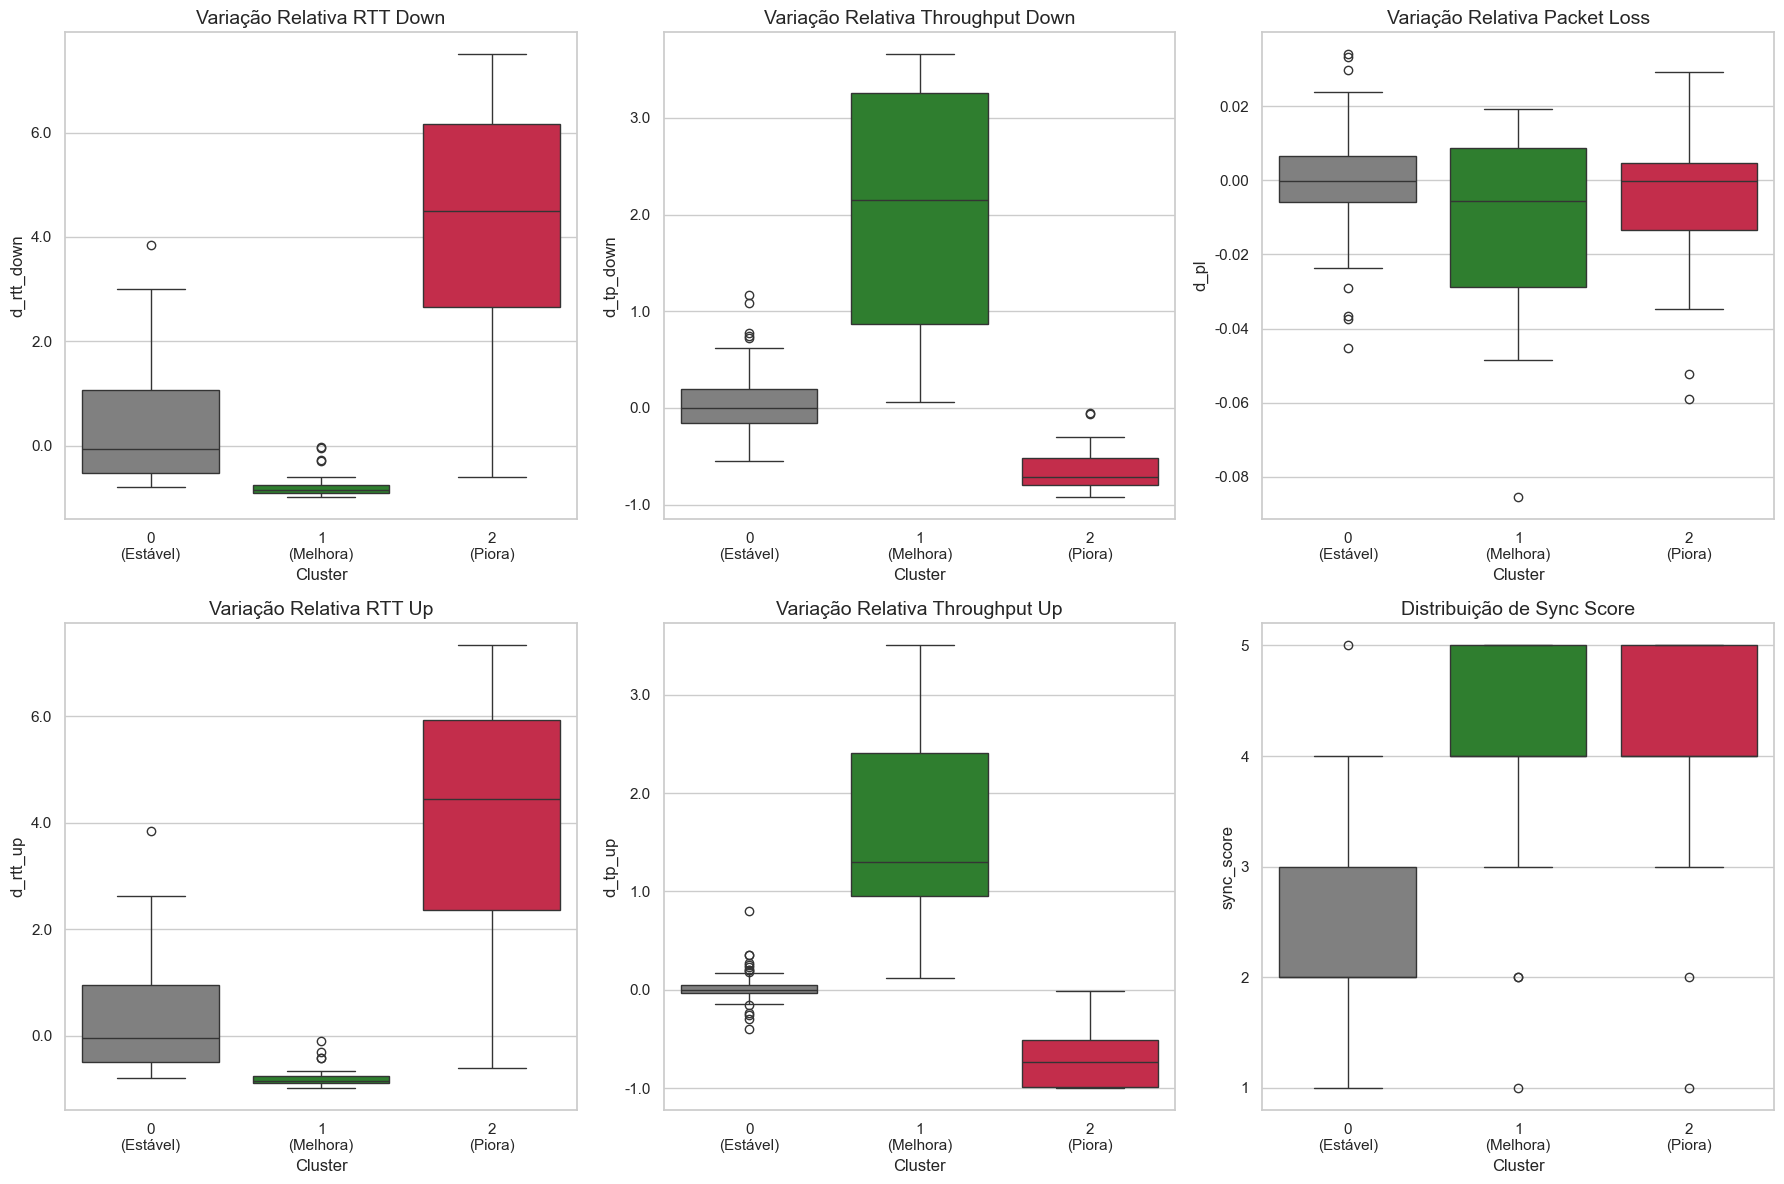

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator, FormatStrFormatter

# Configuração estética dos gráficos
sns.set_theme(style="whitegrid")

# Definir a ordem das métricas para o grid 2x3
# Download e PL em cima (linha 0), Upload e Sync em baixo (linha 1)
metrics_layout = [
    'd_rtt_down', 'd_tp_down', 'd_pl',   # Topo
    'd_rtt_up', 'd_tp_up', 'sync_score'  # Embaixo
]

# Criar a figura com 6 subplots (2 linhas, 3 colunas)
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten() # Achatar a matriz de eixos para facilitar o loop

for i, col in enumerate(metrics_layout):
    ax = axes[i]
    
    # Criar o boxplot usando as cores padronizadas no palette
    sns.boxplot(
        x='cluster', 
        y=col, 
        data=df_cluster, 
        palette=cluster_colors, 
        hue='cluster', 
        legend=False, 
        ax=ax
    )
    
    # Atualizar os rótulos do eixo X com o mapa de clusters
    ax.set_xticks(ax.get_xticks())
    
    # Inserimos uma quebra de linha '\n' antes do parêntese para os textos não ficarem amontoados
    labels = [f"{tick.get_text()}\n({cluster_map.get(int(tick.get_text()), 'Desconhecido')})" 
              for tick in ax.get_xticklabels()]
    ax.set_xticklabels(labels)

    # Forçar ticks inteiros se a variável for o sync_score
    if col == 'sync_score':
        ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    elif col == 'd_pl': 
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    else:
        ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    
    # Pega o título do dicionário ou usa um texto padrão se não existir
    title = metric_info.get(col, f'Distribuição de {col}')
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Cluster', fontsize=12)
    ax.set_ylabel(col, fontsize=12)

plt.tight_layout()
plt.show()

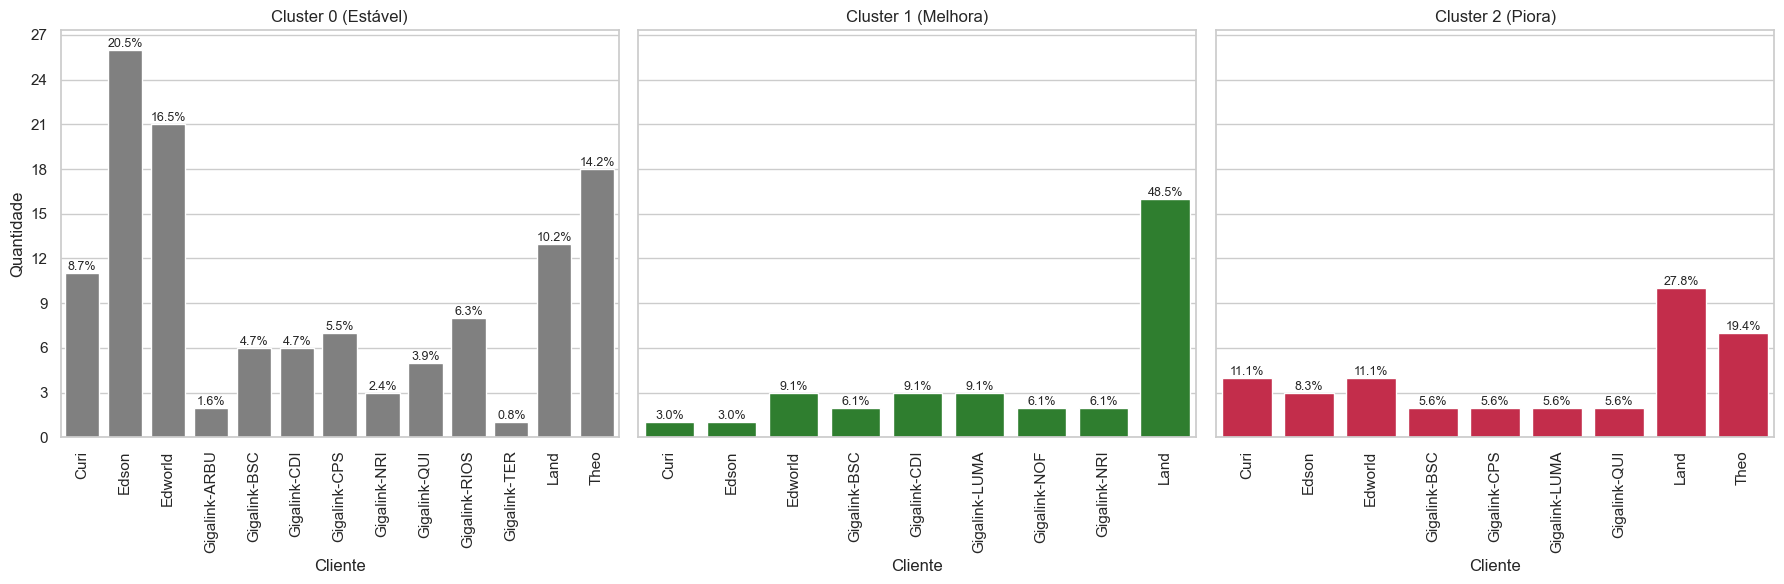

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

df_cluster = df_cluster.sort_values(by=['cluster', 'client'])
clusters = sorted(df_cluster['cluster'].unique())

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, cluster in zip(axes, clusters):
    cluster_data = df_cluster[df_cluster['cluster'] == cluster]
    total = len(cluster_data)
    
    sns.countplot(
        data=cluster_data,
        x='client',
        color=cluster_colors.get(cluster, 'blue'),
        ax=ax
    )
    
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            percentage = f'{100 * height / total:.1f}%'
            ax.annotate(percentage, (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', fontsize=9)
            
    cluster_desc = cluster_map.get(cluster, 'Desconhecido')
    ax.set_title(f'Cluster {cluster} ({cluster_desc})')
    ax.set_ylabel('Quantidade' if ax == axes[0] else '')
    ax.set_xlabel('Cliente')
    ax.tick_params(axis='x', rotation=90)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

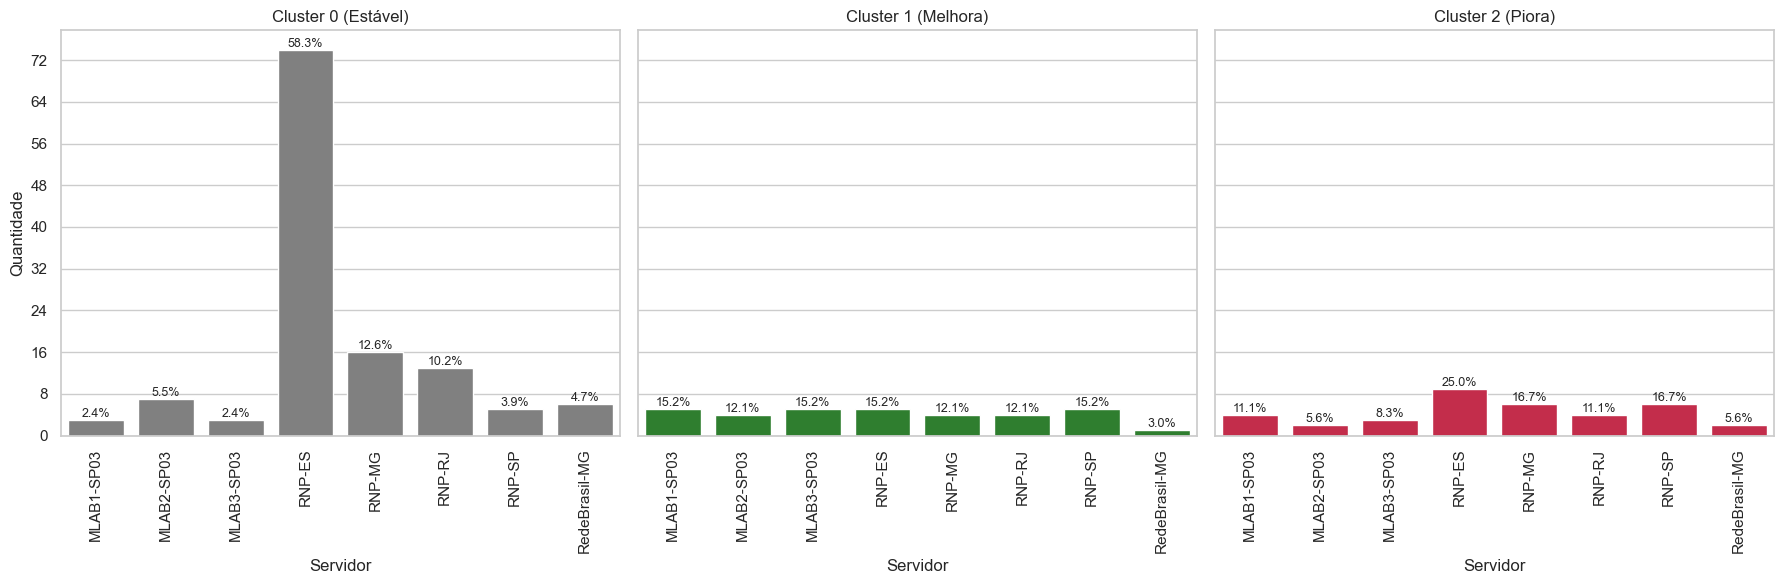

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator

df_cluster = df_cluster.sort_values(by=['cluster', 'server'])
clusters = sorted(df_cluster['cluster'].unique())

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for ax, cluster in zip(axes, clusters):
    cluster_data = df_cluster[df_cluster['cluster'] == cluster]
    total = len(cluster_data)
    
    sns.countplot(
        data=cluster_data,
        x='server',
        color=cluster_colors.get(cluster, 'blue'),
        ax=ax
    )
    
    for p in ax.patches:
        height = p.get_height()
        if height > 0:
            percentage = f'{100 * height / total:.1f}%'
            ax.annotate(percentage, (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', fontsize=9)
            
    cluster_desc = cluster_map.get(cluster, 'Desconhecido')
    ax.set_title(f'Cluster {cluster} ({cluster_desc})')
    ax.set_ylabel('Quantidade' if ax == axes[0] else '')
    ax.set_xlabel('Servidor')
    ax.tick_params(axis='x', rotation=90)
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

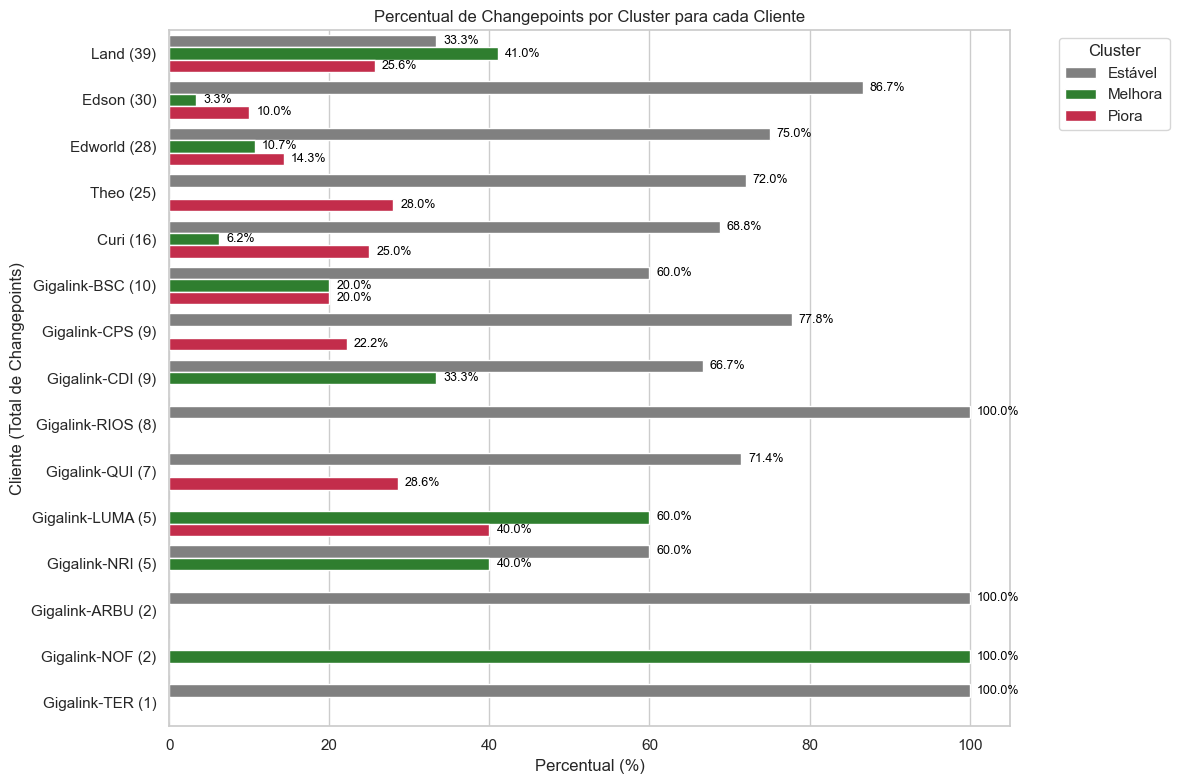

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calcula o total de changepoints por cliente e ordena (decrescente)
client_counts = df_cluster['client'].value_counts()
sorted_clients = client_counts.index.tolist()

# Calcula o percentual de cada cluster por cliente (a soma por cliente é 100%)
percent_df = pd.crosstab(df_cluster['client'], df_cluster['cluster'], normalize='index') * 100
percent_df = percent_df.reset_index().melt(id_vars='client', var_name='cluster', value_name='percentage')

# Cria a nova coluna com o nome do cliente e o total de changepoints
client_counts_dict = client_counts.to_dict()
percent_df['client_label'] = percent_df['client'].apply(lambda c: f"{c} ({client_counts_dict[c]})")

# Cria a lista de labels ordenada para usar no gráfico
sorted_labels = [f"{c} ({client_counts_dict[c]})" for c in sorted_clients]

percent_df['cluster_desc'] = percent_df['cluster'].map(cluster_map)

plt.figure(figsize=(12, 8))
ax = sns.barplot(
    data=percent_df,
    y='client_label',
    x='percentage',
    hue='cluster_desc',
    palette=custom_palette,
    order=sorted_labels
)

plt.title('Percentual de Changepoints por Cluster para cada Cliente')
plt.xlabel('Percentual (%)')
plt.ylabel('Cliente (Total de Changepoints)')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adiciona os valores em texto na frente de cada barra
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f'{width:.1f}%', 
                    (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', 
                    fontsize=9, color='black', 
                    xytext=(5, 0), 
                    textcoords='offset points')

plt.tight_layout()
plt.show()

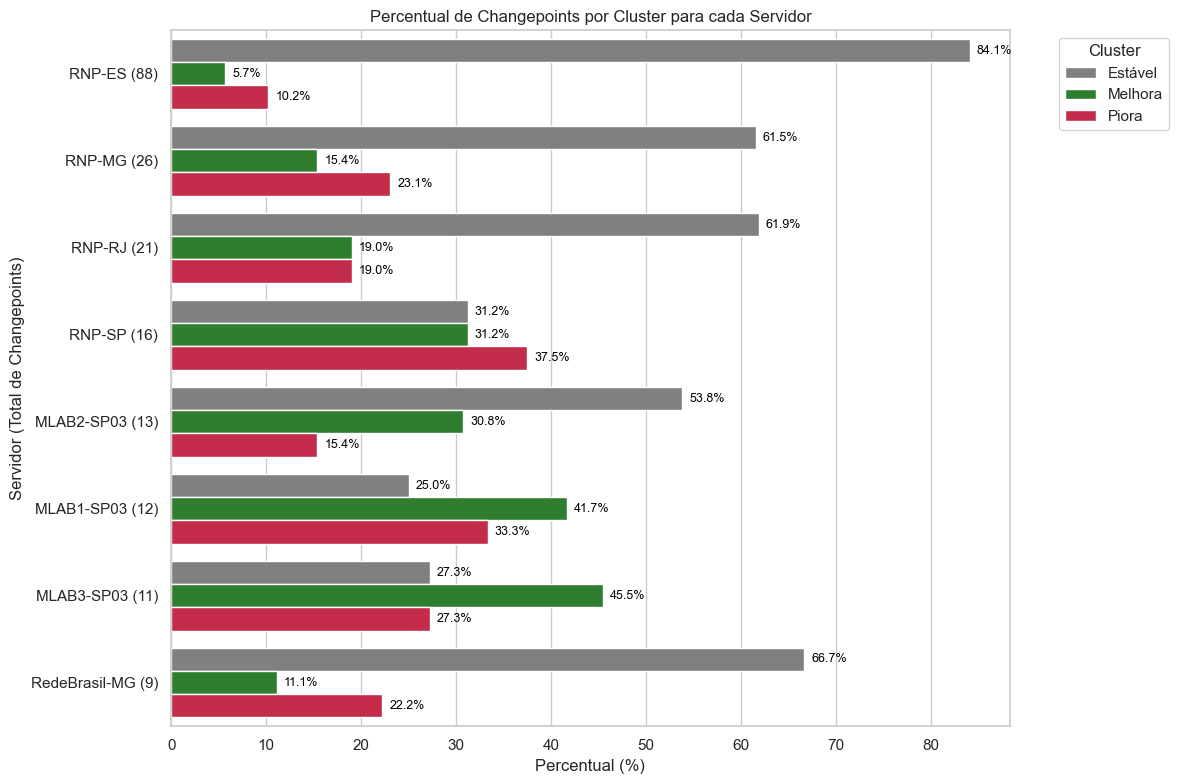

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Calcula o total de changepoints por servidor e ordena (decrescente)
server_counts = df_cluster['server'].value_counts()
sorted_servers = server_counts.index.tolist()

# Calcula o percentual de cada cluster por servidor (a soma por servidor é 100%)
percent_df = pd.crosstab(df_cluster['server'], df_cluster['cluster'], normalize='index') * 100
percent_df = percent_df.reset_index().melt(id_vars='server', var_name='cluster', value_name='percentage')

# Cria a nova coluna com o nome do servidor e o total de changepoints
server_counts_dict = server_counts.to_dict()
percent_df['server_label'] = percent_df['server'].apply(lambda s: f"{s} ({server_counts_dict[s]})")

# Cria a lista de labels ordenada para usar no gráfico
sorted_labels = [f"{s} ({server_counts_dict[s]})" for s in sorted_servers]

percent_df['cluster_desc'] = percent_df['cluster'].map(cluster_map)

plt.figure(figsize=(12, 8))
ax = sns.barplot(
    data=percent_df,
    y='server_label',
    x='percentage',
    hue='cluster_desc',
    palette=custom_palette,
    order=sorted_labels
)

plt.title('Percentual de Changepoints por Cluster para cada Servidor')
plt.xlabel('Percentual (%)')
plt.ylabel('Servidor (Total de Changepoints)')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adiciona os valores em texto na frente de cada barra
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f'{width:.1f}%', 
                    (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', 
                    fontsize=9, color='black', 
                    xytext=(5, 0), 
                    textcoords='offset points')

plt.tight_layout()
plt.show()

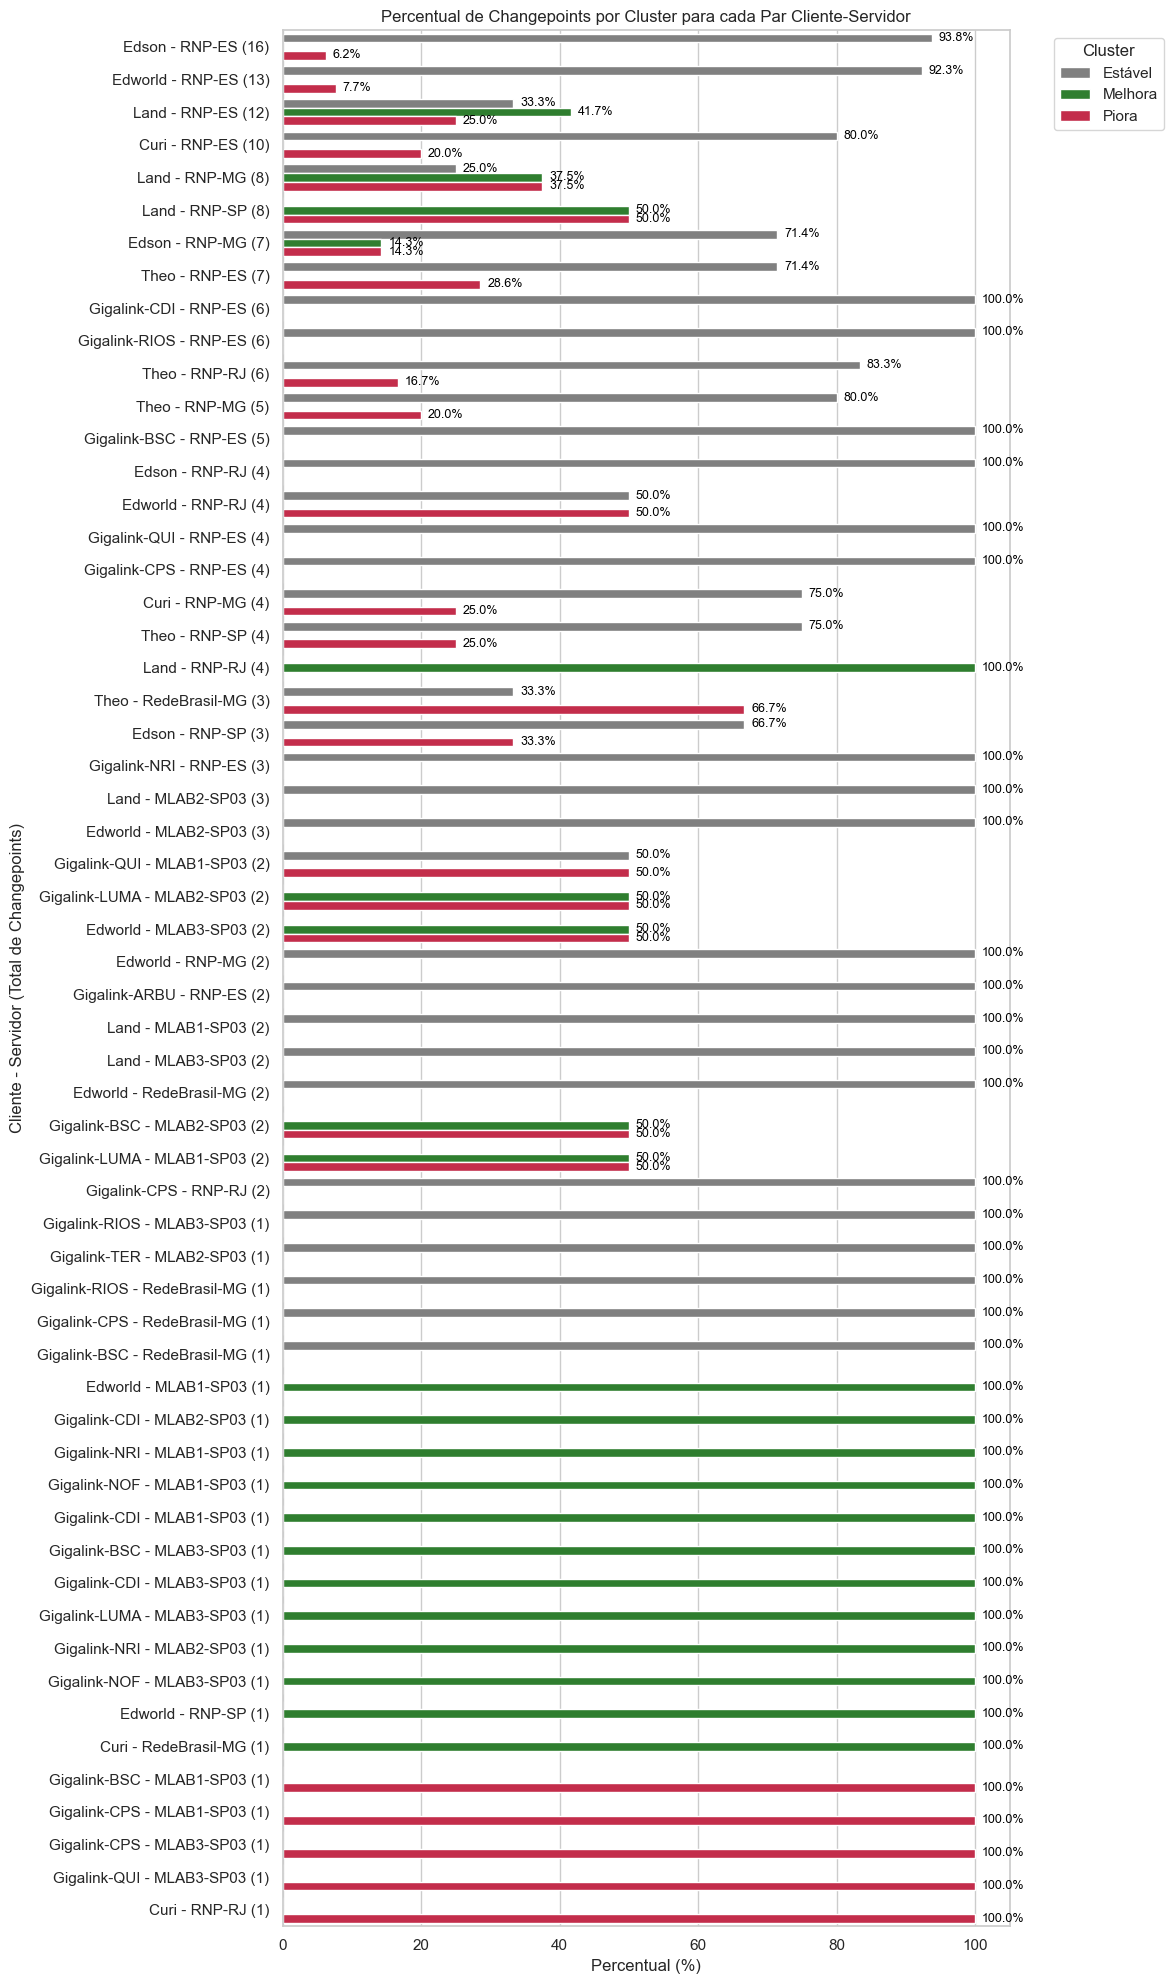

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Cria uma coluna representando o par cliente-servidor
df_cluster['client_server'] = df_cluster['client'] + ' - ' + df_cluster['server']

# Calcula o total de changepoints por par cliente-servidor e ordena (decrescente)
pair_counts = df_cluster['client_server'].value_counts()
sorted_pairs = pair_counts.index.tolist()

# Calcula o percentual de cada cluster por par (a soma por par é 100%)
percent_df = pd.crosstab(df_cluster['client_server'], df_cluster['cluster'], normalize='index') * 100
percent_df = percent_df.reset_index().melt(id_vars='client_server', var_name='cluster', value_name='percentage')

# Cria a nova coluna com o nome do par e o total de changepoints
pair_counts_dict = pair_counts.to_dict()
percent_df['pair_label'] = percent_df['client_server'].apply(lambda p: f"{p} ({pair_counts_dict[p]})")

# Cria a lista de labels ordenada para usar no gráfico
sorted_labels = [f"{p} ({pair_counts_dict[p]})" for p in sorted_pairs]

percent_df['cluster_desc'] = percent_df['cluster'].map(cluster_map)

# Pega só a primeira metade dos pares
# percent_df = percent_df[percent_df['client_server'].isin(sorted_pairs[:len(sorted_pairs)//2])]/

plt.figure(figsize=(12, 20))
ax = sns.barplot(
    data=percent_df,
    y='pair_label',
    x='percentage',
    hue='cluster_desc',
    palette=custom_palette,
    order=sorted_labels # [:len(sorted_pairs)//2]
)

plt.title('Percentual de Changepoints por Cluster para cada Par Cliente-Servidor')
plt.xlabel('Percentual (%)')
plt.ylabel('Cliente - Servidor (Total de Changepoints)')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

# Adiciona os valores em texto na frente de cada barra
for p in ax.patches:
    width = p.get_width()
    if width > 0:
        ax.annotate(f'{width:.1f}%', 
                    (width, p.get_y() + p.get_height() / 2.),
                    ha='left', va='center', 
                    fontsize=9, color='black', 
                    xytext=(5, 0), 
                    textcoords='offset points')

plt.tight_layout()
plt.show()